# 10 · Regression

**Session 13 · Tue Oct 13 · 2 hours**

Regression is the workhorse of applied statistics and the foundation under most of machine learning.
Stripped of notation it is one sentence:

> **Draw the line that comes closest to the points, then read information off the line.**

$$\hat{y} = \beta_0 + \beta_1 x + \varepsilon$$

| Symbol | Meaning |
|---|---|
| `ŷ` | the prediction ("y-hat") |
| `β₀` | intercept — predicted y when x = 0 |
| `β₁` | slope — how much y moves per 1-unit rise in x |
| `ε` | the residual — what the line missed |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

In [2]:
import statsmodels.api as sm
lending = pd.read_csv(DATA / "lending.csv")
lending.head(3)

,loan_id,applicant_group,annual_income,loan_amount,dti_ratio,credit_score,employment_years,region,defaulted
0,LN000000,A,89993.0,4208.0,0.0300,722,4.3,North,1
1,LN000001,B,58401.0,21949.0,0.3993,675,2.1,North,0
2,LN000002,B,84374.0,33372.0,0.4231,646,15.3,Central,0


## 1 · One predictor

Does income predict loan size?

In [3]:
X = sm.add_constant(lending[["annual_income"]])   # add_constant creates the β₀ column
y = lending["loan_amount"]

fit = sm.OLS(y, X).fit()
print(fit.summary().tables[1])

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -415.5492    496.555     -0.837      0.403   -1389.073     557.975
annual_income     0.3277      0.006     54.563      0.000       0.316       0.339


### Reading that table

| Column | Meaning |
|---|---|
| `coef` | the estimated `β` |
| `std err` | standard error of that estimate — same idea as notebook 07 |
| `t` | coef / std err |
| `P>\|t\|` | the p-value for "this coefficient is really zero" |
| `[0.025 0.975]` | 95% confidence interval for the coefficient |

**Say the slope out loud as a sentence.** That habit is what turns a table into a finding:

In [4]:
b0, b1 = fit.params["const"], fit.params["annual_income"]
print(f"β₀ (intercept) = {b0:>12,.2f}")
print(f"β₁ (slope)     = {b1:>12,.4f}")
print()
print(f"In words: every additional $1 of annual income is associated with")
print(f"          ${b1:.4f} more borrowed -- about ${b1*10_000:,.0f} per $10k of income.")
print(f"R² = {fit.rsquared:.4f}  ->  income explains {fit.rsquared:.1%} of the variation in loan size")

β₀ (intercept) =      -415.55
β₁ (slope)     =       0.3277

In words: every additional $1 of annual income is associated with
          $0.3277 more borrowed -- about $3,277 per $10k of income.
R² = 0.4268  ->  income explains 42.7% of the variation in loan size


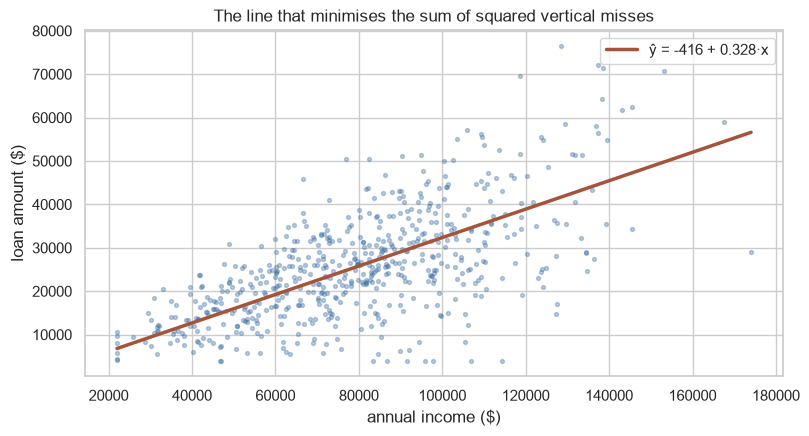

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
samp = lending.sample(600, random_state=1)
ax.scatter(samp.annual_income, samp.loan_amount, s=8, alpha=.35, color="#3b6ea5")
xs = np.linspace(lending.annual_income.min(), lending.annual_income.max(), 100)
ax.plot(xs, b0 + b1*xs, color="#a5533b", lw=2.5, label=f"ŷ = {b0:,.0f} + {b1:.3f}·x")
ax.set_xlabel("annual income ($)"); ax.set_ylabel("loan amount ($)")
ax.set_title("The line that minimises the sum of squared vertical misses")
ax.legend(); plt.show()

## 2 · What "best fit" means

The line is chosen to minimise `Σ(y − ŷ)²` — the sum of squared residuals. Nothing more mysterious
than that. Let's prove no other slope does better.

/Users/ronaldnefiross/PhD/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


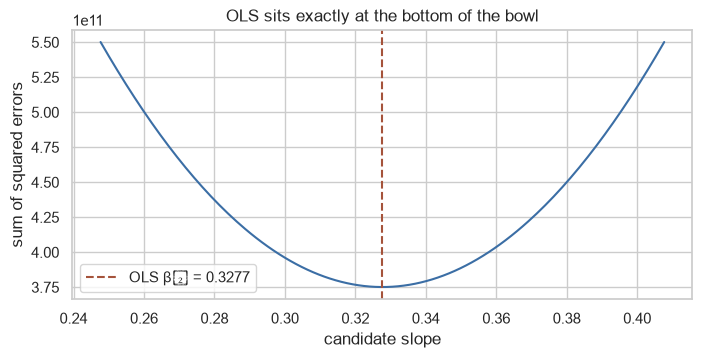

That bowl shape is why squaring matters: it is smooth with one minimum, so
calculus can find the bottom. It is also the shape gradient descent walks down
in machine learning -- same idea, bigger problems.


In [6]:
candidates = np.linspace(b1 - 0.08, b1 + 0.08, 200)
sse = [((y - (b0 + c*lending.annual_income))**2).sum() for c in candidates]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(candidates, sse, color="#3b6ea5")
ax.axvline(b1, color="#a5533b", ls="--", label=f"OLS β₁ = {b1:.4f}")
ax.set_xlabel("candidate slope"); ax.set_ylabel("sum of squared errors")
ax.set_title("OLS sits exactly at the bottom of the bowl")
ax.legend(); plt.show()

print("That bowl shape is why squaring matters: it is smooth with one minimum, so")
print("calculus can find the bottom. It is also the shape gradient descent walks down")
print("in machine learning -- same idea, bigger problems.")

## 3 · Multiple regression, and what "holding constant" means

In [7]:
preds = ["annual_income", "credit_score", "employment_years", "dti_ratio"]
fit2 = sm.OLS(lending["loan_amount"], sm.add_constant(lending[preds])).fit()
print(fit2.summary().tables[1])
print(f"\nR² improved from {fit.rsquared:.4f} to {fit2.rsquared:.4f}")

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2.368e+04    741.593    -31.937      0.000   -2.51e+04   -2.22e+04
annual_income        0.3302      0.003    124.772      0.000       0.325       0.335
credit_score         0.3157      1.008      0.313      0.754      -1.661       2.292
employment_years    -5.0534     14.369     -0.352      0.725     -33.224      23.117
dti_ratio         7.062e+04    541.067    130.518      0.000    6.96e+04    7.17e+04

R² improved from 0.4268 to 0.8912


**The critical shift in interpretation.** In a multiple regression, `β₁` means:

> the change in `y` per 1-unit change in `x₁`, **holding every other predictor fixed**.

That phrase is doing enormous work. It is what lets you separate tangled influences — the effect of
income *at a given credit score and DTI*. It is also the source of most misreadings of regression
output, because "holding constant" is a statement about the arithmetic of the model, not about the
world. If income and credit score always move together in reality, the model's estimate of one
"holding the other fixed" describes a situation that never occurs.

## 4 · Residual plots — how you find out your model is wrong

`R²` can look respectable while the model is badly misspecified. Residual plots catch what `R²` hides.
The rule: **residuals should look like structureless noise.** Any pattern is the model failing.

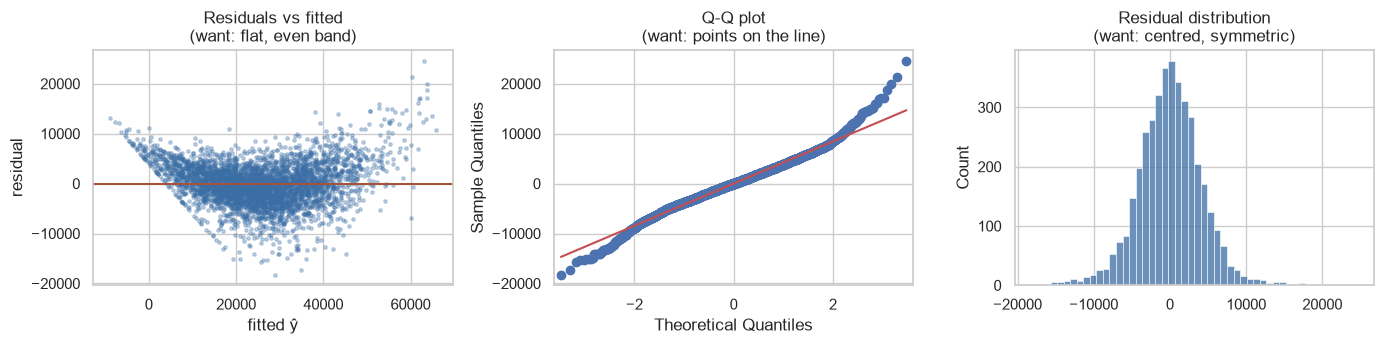

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].scatter(fit2.fittedvalues, fit2.resid, s=6, alpha=.3, color="#3b6ea5")
axes[0].axhline(0, color="#a5533b", lw=1.5)
axes[0].set_xlabel("fitted ŷ"); axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs fitted\n(want: flat, even band)")

sm.qqplot(fit2.resid, line="s", ax=axes[1])
axes[1].set_title("Q-Q plot\n(want: points on the line)")

sns.histplot(fit2.resid, bins=50, ax=axes[2], color="#3b6ea5")
axes[2].set_title("Residual distribution\n(want: centred, symmetric)")
plt.tight_layout(); plt.show()

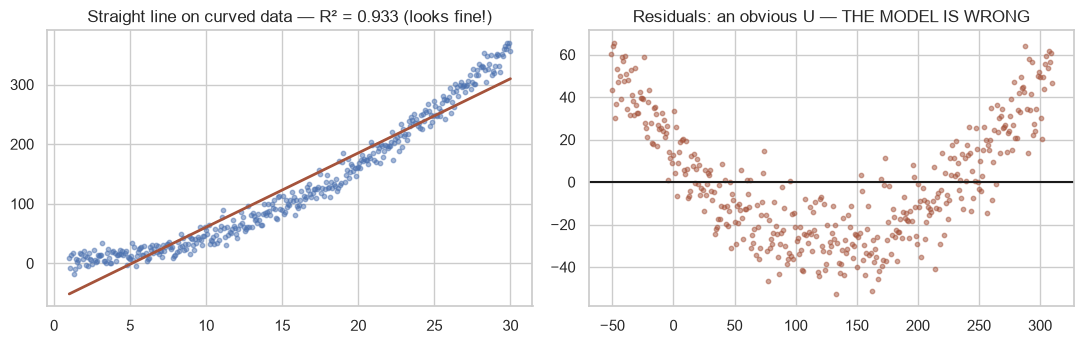

R² = 0.933 would pass most reviews. The residual plot exposes it instantly.
Always plot residuals. R² alone cannot tell you the SHAPE is wrong.


In [9]:
# What a BROKEN model looks like -- fit a straight line to a curve.
x_c = np.linspace(1, 30, 400)
y_c = 5 + 0.4*x_c**2 + rng.normal(0, 12, 400)
bad = sm.OLS(y_c, sm.add_constant(x_c)).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].scatter(x_c, y_c, s=10, alpha=.5); axes[0].plot(x_c, bad.fittedvalues, color="#a5533b", lw=2)
axes[0].set_title(f"Straight line on curved data — R² = {bad.rsquared:.3f} (looks fine!)")
axes[1].scatter(bad.fittedvalues, bad.resid, s=10, alpha=.5, color="#a5533b")
axes[1].axhline(0, color="k")
axes[1].set_title("Residuals: an obvious U — THE MODEL IS WRONG")
plt.tight_layout(); plt.show()

print(f"R² = {bad.rsquared:.3f} would pass most reviews. The residual plot exposes it instantly.")
print("Always plot residuals. R² alone cannot tell you the SHAPE is wrong.")

## 5 · Correlation is not causation — and regression does not fix it

Regression finds associations. It says nothing about cause, no matter how many controls you add or
how small the p-value gets.

In [10]:
# Two variables with no causal link, both driven by a third.
n = 500
branch_size = rng.normal(100, 25, n)             # the hidden common cause
tellers     = 0.08*branch_size + rng.normal(0, 1.2, n)
complaints  = 0.30*branch_size + rng.normal(0, 6, n)

f = sm.OLS(complaints, sm.add_constant(tellers)).fit()
print(f"'effect' of tellers on complaints: {f.params[1]:+.3f}  (p = {f.pvalues[1]:.2e})")
print("Highly significant -- so hire fewer tellers to reduce complaints?\n")

f2 = sm.OLS(complaints, sm.add_constant(np.column_stack([tellers, branch_size]))).fit()
print(f"once branch_size is included: {f2.params[1]:+.3f}  (p = {f2.pvalues[1]:.3f})")
print("\nThe effect vanishes. Big branches have more tellers AND more complaints.")
print("This is CONFOUNDING, and no p-value can warn you about it -- only knowing the")
print("domain can. It is why 'we controlled for observables' is a weak defence, and it")
print("is central to the fairness debate: a model can be statistically impeccable and")
print("still encode a confounded historical process.")

'effect' of tellers on complaints: +2.773  (p = 2.13e-65)
Highly significant -- so hire fewer tellers to reduce complaints?

once branch_size is included: +0.022  (p = 0.922)

The effect vanishes. Big branches have more tellers AND more complaints.
This is CONFOUNDING, and no p-value can warn you about it -- only knowing the
domain can. It is why 'we controlled for observables' is a weak defence, and it
is central to the fairness debate: a model can be statistically impeccable and
still encode a confounded historical process.


## Your turn

**Exercise 1.** Regress `dti_ratio` on `credit_score` and `annual_income`. Report `R²` and write the
`credit_score` coefficient as an English sentence.

In [11]:
# your code here

In [ ]:
m = sm.OLS(lending.dti_ratio,
           sm.add_constant(lending[["credit_score", "annual_income"]])).fit()
print(m.summary().tables[1])
print(f"\nR² = {m.rsquared:.4f}")
print(f"\nA 1-point rise in credit score is associated with a change of "
      f"{m.params['credit_score']:+.6f} in DTI, holding income fixed "
      f"(≈ {m.params['credit_score']*100:+.4f} per 100 points).")

**Exercise 2.** Add `applicant_group` to the loan-amount model as a dummy variable (hint:
`pd.get_dummies(..., drop_first=True)` and cast to `float`). Interpret its coefficient carefully —
and note what you would need to know before calling it evidence of anything.

In [13]:
# your code here

In [ ]:
d = pd.get_dummies(lending[["annual_income","credit_score","applicant_group"]],
                   drop_first=True).astype(float)
m = sm.OLS(lending.loan_amount, sm.add_constant(d)).fit()
print(m.summary().tables[1])

print("\nThe applicant_group_B coefficient is the average difference in loan amount")
print("between group B and group A AT THE SAME income and credit score.")
print()
print("What it is NOT: evidence of discrimination. Loan amount is largely applicant-")
print("DEMANDED, not lender-assigned, and the model omits wealth, family size, purpose,")
print("and local prices. A coefficient is a starting question, not a finding. That")
print("distinction -- between a statistical association and a normative claim -- is")
print("exactly what a PhDAI 832 paper has to get right.")

## What you did today

- Regression as a line fitted by minimising `Σ(y − ŷ)²`, and saw the bowl it sits at the bottom of.
- Read a `statsmodels` table and said coefficients aloud as sentences.
- Learned what "holding constant" really claims — and its limits.
- **Residual plots**, and saw an `R²` of 0.9 hiding a badly wrong model.
- Confounding: a strong, significant, entirely spurious effect, killed by one control.

**Next:** `11_model_evaluation.ipynb` — the final notebook, where both courses meet.